# Detección de plagio en código fuente — Dataset AI-SOCO — MLP TF-IDF

El plagio en código aparece de dos formas distintas, que requieren señales diferentes para ser detectadas:

| Tipo | Pregunta | ¿Nuestro dataset permite medirlo? |
|---|---|---|
| **Suplantación** | ¿Este código coincide con el estilo de su autor declarado? | Sí — hay etiquetas de autor en train/dev |
| **Copia** | ¿Estos dos códigos se parecen demasiado entre sí? | Parcialmente — no hay parejas etiquetadas como copia, por lo que se debe inspeccionar manualmente |

**Diseño del experimento:** se aprende la *firma de estilo* de cada uno de los 1,000 autores con un modelo BPE + TF-IDF + MLP, y se evalúa no por su accuracy de clasificación — que es solo la tarea intermedia — sino con métricas de la tarea de plagio: **AUC de verificación** ("¿misma mano?") y **detección de suplantación a 5% de falsas alarmas** ("¿es de quien dice ser?"). Al final, la búsqueda de copias dentro de test con control de plantillas.

**Datos** (Parquet generados por `ETL.ipynb`, UTF-8): train 40,000, validation 10,000, dev 25,000, test 25,000 (sin autor; búsqueda de copias). Columnas: `uid` (autor), `pid` (id único de archivo), `code` (programa C++).

In [19]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Evita mensajes de advertencia de TensorFlow sobre la GPU

import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from tensorflow import keras

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel

from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, roc_curve

In [20]:
# GPU, rutas y reproducibilidad
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
print('GPU:', physical_devices[0].name if physical_devices else 'no disponible (CPU)')

OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)
SEED = 42
keras.utils.set_random_seed(SEED)

GPU: /physical_device:GPU:0


In [ ]:
# Carga de datos y codificacion de autores a indices 0-999
train = pd.read_parquet('train_fit_processed.parquet')
val = pd.read_parquet('val_processed.parquet')
dev = pd.read_parquet('dev_processed.parquet')
test = pd.read_parquet('test_processed.parquet')

le = LabelEncoder().fit(train['uid'])
y_train = le.transform(train['uid']).astype('int32')
y_val = le.transform(val['uid']).astype('int32')
y_dev = le.transform(dev['uid']).astype('int32')
num_classes = len(le.classes_)
joblib.dump(le, OUTPUT_DIR / 'label_encoder_model_1.joblib')

print(f'train {train.shape} | val {val.shape} | dev {dev.shape} | test {test.shape} | autores: {num_classes}')

train (40000, 5) | val (10000, 5) | dev (25000, 5) | test (25000, 3) | autores: 1000


## Representación del código

1. **Tokenización BPE byte-level** (`tokenizers` de Hugging Face): vocabulario de 20,000 subpalabras aprendido **solo sobre train** (sin filtrar información de dev/test). Al operar a nivel de bytes preserva espacios y puntuación, que es donde vive la huella estilística de un programador (`cin>>a` vs `cin >> a`).

2. **TF-IDF de n-gramas BPE** (uni+bigramas, 30,000 dims): *qué* fragmentos usa cada autor, sin orden.

In [22]:
# Tokenizador BPE (entrenado solo con train)
tokenizer = Tokenizer(BPE(unk_token='<unk>'))
tokenizer.pre_tokenizer = ByteLevel(add_prefix_space=False)
trainer = BpeTrainer(vocab_size=20000, min_frequency=2,
                     special_tokens=['<unk>'], initial_alphabet=ByteLevel.alphabet())
tokenizer.train_from_iterator(train['code'].tolist(), trainer=trainer)
tokenizer.save(str(OUTPUT_DIR / 'bpe_tokenizer_model_1.json'))

def to_id_text(codes):
    return [' '.join(map(str, e.ids)) for e in tokenizer.encode_batch(list(codes))]

print('Vocabulario BPE:', tokenizer.get_vocab_size())




Vocabulario BPE: 20000


In [23]:
# test se incluye porque la busqueda de copias usa las predicciones del modelo sobre test.
vec = TfidfVectorizer(token_pattern=r'[^ ]+', ngram_range=(1, 2), min_df=2,
                      max_features=30000, sublinear_tf=True, dtype=np.float32)

X1_train = vec.fit_transform(to_id_text(train['code'])).toarray()
X1_val = vec.transform(to_id_text(val['code'])).toarray()
X1_dev = vec.transform(to_id_text(dev['code'])).toarray()
X1_test = vec.transform(to_id_text(test['code'])).toarray()
joblib.dump(vec, OUTPUT_DIR / 'tfidf_vectorizer_model_1.joblib')

['output/tfidf_vectorizer_model_1.joblib']

## Modelo de firma de estilo: MLP sobre TF-IDF

Un clasificador de los 1,000 autores sobre la representación bolsa de n-gramas. La señal de plagio se *deriva* de sus probabilidades y similitudes en la sección de evaluación. El modelo no necesita ver el orden de los tokens: con saber *qué* fragmentos usa cada autor, y con qué frecuencia, ya puede distinguir estilos.

In [24]:
# MLP sobre TF-IDF denso
model_a = keras.Sequential([
    keras.layers.Input(shape=(X1_train.shape[1],)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(num_classes),
], name='mlp_model_1')
model_a.compile(optimizer=keras.optimizers.Adam(1e-3),
                loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])

history_a = model_a.fit(X1_train, y_train,
                        validation_data=(X1_val, y_val),
                        batch_size=256, epochs=30,
                        callbacks=[keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                                                 patience=5,
                                                                 restore_best_weights=True)])
model_a.save(str(OUTPUT_DIR / 'mlp_model_1.keras'))

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.2850 - loss: 5.8377 - val_accuracy: 0.5235 - val_loss: 3.9589
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.6048 - loss: 2.8405 - val_accuracy: 0.7098 - val_loss: 2.0982
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7732 - loss: 1.5865 - val_accuracy: 0.8056 - val_loss: 1.4003
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8573 - loss: 1.0065 - val_accuracy: 0.8521 - val_loss: 1.0455
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9080 - loss: 0.6770 - val_accuracy: 0.8789 - val_loss: 0.8446
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9375 - loss: 0.4744 - val_accuracy: 0.8905 - val_loss: 0.7216
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9576 - loss: 0.3354 - val_accuracy: 0.9008 - val_loss: 0.6415
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9703 - loss: 0.2430 - val_accu

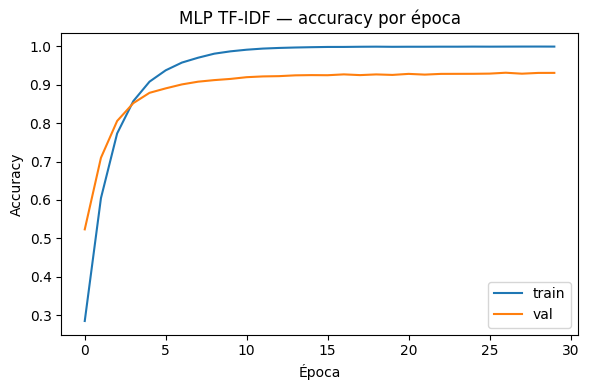

In [25]:
# Curva de validacion
plt.figure(figsize=(6, 4))
plt.plot(history_a.history['accuracy'], label='train')
plt.plot(history_a.history['val_accuracy'], label='val')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('MLP TF-IDF — accuracy por época')
plt.legend()
plt.tight_layout()
plt.show()

## Evaluación del modelo
Con las mediciones de el accuracy al momento de identificar los autores, también evaluamos qué tan útil es el modelo en cuanto a la detección de plagio entre códigos.

### Verificación de los autores
En esta parte es donde generamos pares de códigos del conjunto de desarrollo, sin importar que pertenezcan al mismo autor u otro autores. Para poder comparar ambos códigos lo que hacemos es calcular la similitud utilizando `TF-IDF`, si la similitud es muy alta es más probable que ambos programas hayan sido escritos por la misma persona. 
<br>El desempeño lo medimos con la métrica AUC("Area Under Curve") que se utiliza para evaluar modelos de clasificación binaria, en nuestro caso es, que tan bien logra distinguir entre pares del mismo autor y pares de autores distintos. 

### Suplantación de autor
Tabién evalumamos si el código realmente le pertenece al autor que se declara. Para eso ocupamos probar cada programa dos veces:
- Con el autor verdadero
- Con un autor falso (seleccionado aleatoriamente).
<br> Eso lo medimos con la capa `softmax` para medir la confianza del modelo y despues calculamos el AUC y la tasa de detección de impostores.

### Accuracy de autoria
Como métrica adicional reportamos el accuracy de clasificación de autores y el Top-5 para poder conocer qué tan bien esta el modelo identificando al autor correcto entre los 1,000 posibles autores del dataset.

In [26]:
# Pares de evaluacion y autores falsos
def generar_pares(y, n_pares, rng):
    """Pares de indices: mitad mismo autor (etiqueta 1), mitad autores distintos (etiqueta 0)."""
    y = np.asarray(y)
    indices_por_autor = {a: np.where(y == a)[0] for a in np.unique(y)}
    autores = np.array([a for a, idxs in indices_por_autor.items() if len(idxs) >= 2])
    mitad = n_pares // 2

    ia, ib, etiquetas = [], [], []
    for a in rng.choice(autores, size=mitad, replace=True):
        i, j = rng.choice(indices_por_autor[a], size=2, replace=False)
        ia.append(i); ib.append(j); etiquetas.append(1)
    todos = np.array(list(indices_por_autor.keys()))
    for _ in range(mitad):
        a1, a2 = rng.choice(todos, size=2, replace=False)
        ia.append(rng.choice(indices_por_autor[a1]))
        ib.append(rng.choice(indices_por_autor[a2]))
        etiquetas.append(0)
    return np.array(ia), np.array(ib), np.array(etiquetas, dtype='float32')

rng_eval = np.random.default_rng(SEED)
N_PARES_EVAL = 20000
ia_ev, ib_ev, lab_ev = generar_pares(y_dev, N_PARES_EVAL, rng_eval)

n_dev = len(y_dev)
uid_falso = rng_eval.integers(0, num_classes, size=n_dev)
mask = uid_falso == y_dev
while mask.any():  # reasignar coincidencias accidentales con el autor verdadero
    uid_falso[mask] = rng_eval.integers(0, num_classes, size=mask.sum())
    mask = uid_falso == y_dev

tabla = {}
rocs  = {}

def top_k_acc(probs, y, k=5):
    topk = np.argpartition(probs, -k, axis=1)[:, -k:]
    return float((topk == np.asarray(y)[:, None]).any(axis=1).mean())

def evaluar(nombre, sims_pares, score_gen, score_imp, acc=None, top5=None, fa=0.05):
    """Calcula las metricas de plagio del modelo y las agrega a la tabla final."""
    auc_v = roc_auc_score(lab_ev, sims_pares)
    fpr_v, tpr_v, _ = roc_curve(lab_ev, sims_pares)

    y_s = np.concatenate([np.ones(len(score_imp)), np.zeros(len(score_gen))])
    s_s = np.concatenate([-np.asarray(score_imp), -np.asarray(score_gen)])  # score bajo => sospechoso
    auc_s = roc_auc_score(y_s, s_s)
    fpr_s, tpr_s, _ = roc_curve(y_s, s_s)
    deteccion = tpr_s[max(np.searchsorted(fpr_s, fa, side='right') - 1, 0)]

    tabla[nombre] = {'Accuracy autoría': acc, 'Top-5 autoría': top5,
                     'AUC verificación': round(auc_v, 4),
                     'AUC suplantación': round(auc_s, 4),
                     'Detección @5% FA': round(deteccion, 4)}
    rocs[nombre] = {'verificacion': (fpr_v, tpr_v), 'suplantacion': (fpr_s, tpr_s)}
    print(f'[{nombre}] AUC verificación: {auc_v:.4f} | AUC suplantación: {auc_s:.4f} | '
          f'detección @5% FA: {deteccion:.2%}')

In [27]:
# Evaluacion: similitud coseno TF-IDF (filas ya normalizadas L2) + softmax del autor declarado
probs_a = tf.nn.softmax(model_a.predict(X1_dev, batch_size=512, verbose=0)).numpy()
sims_a  = (X1_dev[ia_ev] * X1_dev[ib_ev]).sum(axis=1)

evaluar('MLP TF-IDF', sims_a,
        probs_a[np.arange(n_dev), y_dev],
        probs_a[np.arange(n_dev), uid_falso],
        acc=float((probs_a.argmax(axis=1) == y_dev).mean()),
        top5=top_k_acc(probs_a, y_dev))

[MLP TF-IDF] AUC verificación: 0.9188 | AUC suplantación: 0.9987 | detección @5% FA: 99.98%


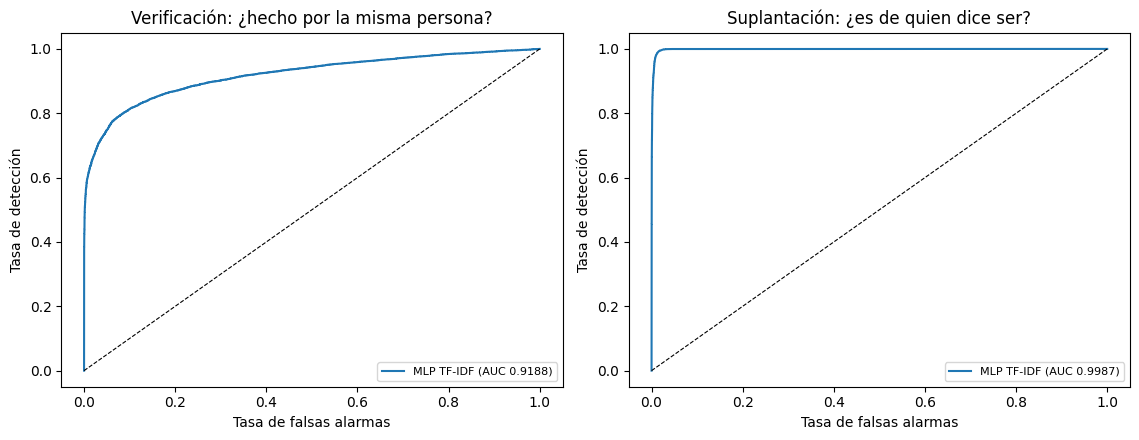

            Accuracy autoría  Top-5 autoría  AUC verificación  AUC suplantación  Detección @5% FA
MLP TF-IDF           0.92932        0.96388            0.9188            0.9987            0.9998


In [28]:
# Curvas ROC para las dos preguntas de plagio
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
fpr_v, tpr_v = rocs['MLP TF-IDF']['verificacion']
fpr_s, tpr_s = rocs['MLP TF-IDF']['suplantacion']
axes[0].plot(fpr_v, tpr_v, label=f"MLP TF-IDF (AUC {tabla['MLP TF-IDF']['AUC verificación']})")
axes[1].plot(fpr_s, tpr_s, label=f"MLP TF-IDF (AUC {tabla['MLP TF-IDF']['AUC suplantación']})")
for ax, titulo in zip(axes, ['Verificación: ¿hecho por la misma persona?', 'Suplantación: ¿es de quien dice ser?']):
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_xlabel('Tasa de falsas alarmas')
    ax.set_ylabel('Tasa de detección')
    ax.set_title(titulo)
    ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

df_resultados = pd.DataFrame(tabla).T
print(df_resultados.to_string())
df_resultados.to_csv(OUTPUT_DIR / 'resultados_clasificacion.csv')

## Interpretación de la Evaluación
Podemos ver que los resultados obtenidos demuestran que el modelo es capaz de detectar ciertos patrones/costumbres de los autores a partir de sus programas. Esto lo podemos ver con el accuracy como en los valores del AUC que se obtuvieron durante las pruebas de verificación.
<br>En la prueba de verificación con similitud coseno sobre los vectores de TF-IDF logro diferenciar en muchos casos códigos que fueron escritos por el mismo autor de los que fueron hechos por autores distintos. Aunque esta técnica se basa principalmente en las palabras y estructuras presentes en el código puede presentar problemas cuando hay diferentes autores que resuelven el mismo problema de una forma muy similar o simplemente los que utilizan plantillas similares para resolver un mismo problema. 
<br>En la prueba de suplantación el modelo mostró una buena capacidad para poder identificar cuando un código no pertenece al autor que fue declarado, la métrica de detección con 5% de falsas alarmas permite observar el equilibrio entre detectar impostores y poder evitar que se rechacen autores correctos. Cuando el porcentaje sea más grande se dice que la capacidad del sistema es mejor para detectar casos sospechosos. Es importante notar que la suplantación simulada no representa completamente un caso real de plagio, ya que pueden existir modificaciones intencionales en el código, cambios de variables, comentarios o técnica para ocultar la copia de código. Aun asi con esta evaluación medimos una aproximación útil para medir qué tan bien el modelo esta distinguiendo los estilos de programación diferentes. 

## Búsqueda de posibles copias
Utilizando el conjunto de prueba no estamos contando con las etiquetas reales de los autores por lo que esta etapa solo la estamos utilizando para poder encontrar códigos que podrían ser sospechosos en cuanto a similitudes y qué vendría bien una revisión manual.
<br> La búsqueda la realizamos comparando cada archivo con los demaás para poder encontrar los vecinos más cercanos, ya que a cada archivo le corresponde un identificador único no podemos agruparlos por problema, la comparación debe hacerse entre todos los códigos que tenemos disponibles. 
<br> Muchos programas de manera natural comparten estructuras comunes de programación, como las librerías, plantillas o marcos. Esto solo puede generar similitudes altas aunque los códigos no sean copias, para poder reducir esto eliminamos elementos frecuentes antes de realizar las comparaciones.
<br> Las parejas encontradas con mayor similitud pueden indicar que ambos códigos comparten gran parte de la soluciókn pero una similitud alta no garantiza que exista plagio en el código, ya que las personas pueden utilizar plantillas y estilos muy similares. 
<br>
Es por eso que los resultados que obtuvimos se debe considerar como una lista de candidatios a revisión y no como una prueba definitiva de plagio. 

In [29]:
# Prediccion de autor para los codigos de test (usando el modelo MLP)
probs_test = tf.nn.softmax(model_a.predict(X1_test, batch_size=512, verbose=0)).numpy()
test_preds = test[['pid']].copy()
test_preds['pred_uid'] = le.inverse_transform(probs_test.argmax(axis=1))
test_preds['confidence'] = probs_test.max(axis=1)
test_preds.to_csv(OUTPUT_DIR / 'test_predictions_model_1.csv', index=False)
joblib.dump(test_preds, OUTPUT_DIR / 'test_predictions_model_1.joblib')
print('Predicciones guardadas:', len(test_preds))

Predicciones guardadas: 25000


In [30]:
def buscar_parejas(X_sim, preds, threshold=0.80, k=6):
    """Parejas de codigos con similitud coseno >= threshold, anotadas con autor predicho."""
    nn = NearestNeighbors(n_neighbors=k, metric='cosine').fit(X_sim)
    distances, neighbor_idx = nn.kneighbors(X_sim)
    similarities = 1.0 - distances

    seen, suspects = set(), []
    for i in range(X_sim.shape[0]):
        for pos in range(1, k):
            j = int(neighbor_idx[i, pos])
            sim = float(similarities[i, pos])
            if j == i or sim < threshold:
                continue
            pair = (min(i, j), max(i, j))
            if pair in seen:
                continue
            seen.add(pair)
            a, b = pair
            suspects.append({'pid_a': preds.loc[a, 'pid'], 'pid_b': preds.loc[b, 'pid'],
                             'cosine_sim': round(sim, 4),
                             'pred_uid_a': preds.loc[a, 'pred_uid'],
                             'pred_uid_b': preds.loc[b, 'pred_uid'],
                             'conf_a': round(float(preds.loc[a, 'confidence']), 3),
                             'conf_b': round(float(preds.loc[b, 'confidence']), 3)})
    df = pd.DataFrame(suspects, columns=['pid_a', 'pid_b', 'cosine_sim', 'pred_uid_a',
                                         'pred_uid_b', 'conf_a', 'conf_b'])
    df['same_pred_uid'] = df['pred_uid_a'] == df['pred_uid_b']
    return df.sort_values('cosine_sim', ascending=False).reset_index(drop=True)

In [31]:
# Control de plantilla: eliminar lineas que aparecen en >=1% de los archivos de test
line_freq = Counter()
for code_ in test['code']:
    line_freq.update({l.strip() for l in code_.splitlines() if l.strip()})
LINEAS_COMUNES = {linea for linea, c in line_freq.items() if c >= 0.01 * len(test)}
print(f'Líneas-plantilla eliminadas (en ≥1% de los archivos): {len(LINEAS_COMUNES):,}')

def quitar_plantilla(code_):
    return '\n'.join(l for l in code_.splitlines() if l.strip() not in LINEAS_COMUNES)

vec_copias = TfidfVectorizer(token_pattern=r'[^ ]+', ngram_range=(1, 2), min_df=2,
                             max_df=0.3, max_features=30000, sublinear_tf=True,
                             dtype=np.float32)
X_copias = vec_copias.fit_transform(to_id_text(test['code'].map(quitar_plantilla)))

pairs = buscar_parejas(X_copias, test_preds)
print(f'Parejas candidatas (similitud >= 0.80): {len(pairs):,} | '
      f'entre autores predichos distintos: {int((~pairs.same_pred_uid).sum()):,}')
print(pairs.head(15).to_string())
pairs.to_csv(OUTPUT_DIR / 'plagiarism_within_test_sin_plantilla.csv', index=False)

Líneas-plantilla eliminadas (en ≥1% de los archivos): 271
Parejas candidatas (similitud >= 0.80): 6,690 | entre autores predichos distintos: 16
    pid_a  pid_b  cosine_sim  pred_uid_a  pred_uid_b  conf_a  conf_b  same_pred_uid
0   99044  31059      1.0000         809         809   0.220   0.220           True
1   16815  88194      1.0000         504         504   0.992   0.992           True
2   59528  81766      1.0000         832         832   1.000   1.000           True
3   36827  21864      1.0000         979         979   1.000   1.000           True
4   69460  62051      1.0000         416         416   1.000   1.000           True
5   94772  96018      1.0000         464         464   0.997   0.997           True
6   60143  30545      1.0000         126         126   0.901   0.901           True
7   95706   5984      1.0000         168         168   1.000   1.000           True
8   28053  87428      1.0000         999         999   0.999   0.999           True
9   47788   2713

In [32]:
# Inspeccion: la pareja mas sospechosa ENTRE PERSONAS DISTINTAS (el caso que importa)
candidatas = pairs[~pairs['same_pred_uid']]
fila = candidatas.iloc[0] if len(candidatas) else pairs.iloc[0]

code_a = test.loc[test['pid'] == fila['pid_a'], 'code'].iloc[0]
code_b = test.loc[test['pid'] == fila['pid_b'], 'code'].iloc[0]
print(f"Similitud: {fila['cosine_sim']} | autores predichos: "
      f"{fila['pred_uid_a']} vs {fila['pred_uid_b']} | ¿idénticos?: {code_a == code_b}\n")
print(f"--- pid {fila['pid_a']} (primeras 25 líneas) ---")
print('\n'.join(code_a.splitlines()[:25]))
print(f"\n--- pid {fila['pid_b']} (primeras 25 líneas) ---")
print('\n'.join(code_b.splitlines()[:25]))

Similitud: 0.8871 | autores predichos: 383 vs 275 | ¿idénticos?: False

--- pid 93357 (primeras 25 líneas) ---
#ifndef _GLIBCXX_NO_ASSERT
#include <cassert>
#endif
#include <cctype>
#include <cerrno>
#include <cfloat>
#include <ciso646>
#include <climits>
#include <clocale>
#include <cmath>
#include <csetjmp>
#include <csignal>
#include <cstdarg>
#include <cstddef>
#include <cstdio>
#include <cstdlib>
#include <cstring>
#include <ctime>

#if __cplusplus >= 201103L
#include <ccomplex>
#include <cfenv>
#include <cinttypes>
#include <cstdbool>
#include <cstdint>

--- pid 80393 (primeras 25 líneas) ---
#ifndef _GLIBCXX_NO_ASSERT
#include <cassert>
#endif
#include <cctype>
#include <cerrno>
#include <cfloat>
#include <ciso646>
#include <climits>
#include <clocale>
#include <cmath>
#include <csetjmp>
#include <csignal>
#include <cstdarg>
#include <cstddef>
#include <cstdio>
#include <cstdlib>
#include <cstring>
#include <ctime>

#if __cplusplus >= 201103L
#include <ccomplex>
#include <cfenv>

## Interpretación de la búsqueda de plagio
Despues de aplicar los filtros para reducir el efecto de las plantillas compartidas, obtuvimos varias parejas de códigos con muchas similitudes. Estas parejas representan candidatos a revisión ya que una similitud elevada puede indicar que comparten gran parte de la misma solución.
<br> No todas las coincidencias pertenecen a casos de plagio, en algunos casos diferentes programadores pueden utilizar estructuras similares, librerías comúnes o incluso plantillas similares para resolver problemas de programación. 
Una limitación importante de esta etapa es que el conjunto de prueba no contiene etiquetas que indiquen cuáles casos son realmente copias y cuáles no, gracias a esto no es posible calcular métricas como precisión o recall.
<br> En lugar de medir el desempeño con estas métricas, el objetivo es generar una lista de casos sospechosos para que despues se revisen de manera manual, de esta forma el sistema funciona como una herramienta de apoyo para identificar posibles casos de copia.

## ✏️ Conclusiones

Usar n-gramas BPE combina las ventajas tanto de enfoques basados en palabras como en caracteres. En comparación con un TF-IDF de palabras, el BPE puede manejar mejor la variabilidad en el código, como nombres de variables o espacios. En comparación con un TF-IDF de caracteres, el BPE puede "aprender" fragmentos con mayor reelevancia estilística, permitiendo una representación compacta y efectiva del estilo de programación de cada autor.

En el desarrollo del modelo, nos encontramos con distintas limitaciones, la más importante siendo la calidad del dataset, ya que no contamos con etiquetas de copia/autor real en el conjunto de prueba, lo que limita la evaluación a métricas de verificación y suplantación simulada (puesto que AI-SOCO es originalmente un dataset de competencia), esto reduce en 25,000 el número de ejemplos disponibles para evaluar la detección de plagio, y hace que la búsqueda de copias dentro de test solo pueda ser un triaje para revisión manual. 

Al ser un modelo basado en TF-IDF, se ignora el orden de los tokens y se considera únicamente su frecuencia. Esto genera una pérdida de información sobre la estructura y el flujo del código. Un modelo secuencial como un Transformer podría capturar patrones relacionados con la sintaxis y el órden de los tokens, lo que podría ser especialmente útil para detectar suplantación. Generar copias sintéticas de código para medir recall también sería un paso importante para evaluar la capacidad del modelo para detectar casos de plagio más complejos.